In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [20]:
from sklearn import linear_model, preprocessing, model_selection, pipeline, metrics
import matplotlib.pyplot as plt

In [15]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm','PetalWidthCm']]
y = df.Species
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LogisticRegression()),
])
pipe.fit(X_train, y_train)


y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

[[18  0  0]
 [ 0 10  0]
 [ 0  1 16]]
accuracy:  0.9777777777777777


In [25]:
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

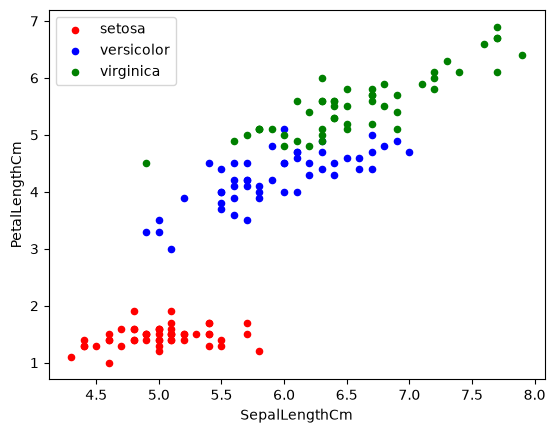

In [37]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

In [32]:
from mlxtend.plotting.decision_regions import plot_decision_regions
import numpy as np

[[31  4]
 [10  0]]
accuracy:  0.6888888888888889


/home/aio/training/AI/LangchainDemos/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


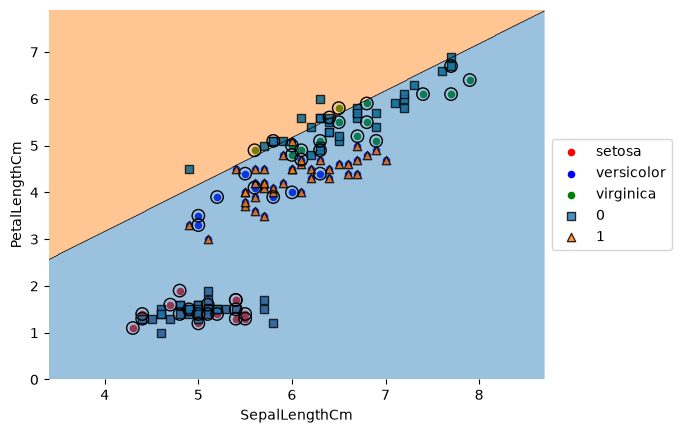

In [39]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

y = np.where(df.Species == 'Iris-versicolor', 1, 0)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LogisticRegression()),
])
pipe.fit(X_train, y_train)


y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

plot_decision_regions(X_train.values, y_train, pipe, X_highlight=X_test.values)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

[[31  4]
 [ 0 10]]
accuracy:  0.9111111111111111


/home/aio/training/AI/LangchainDemos/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


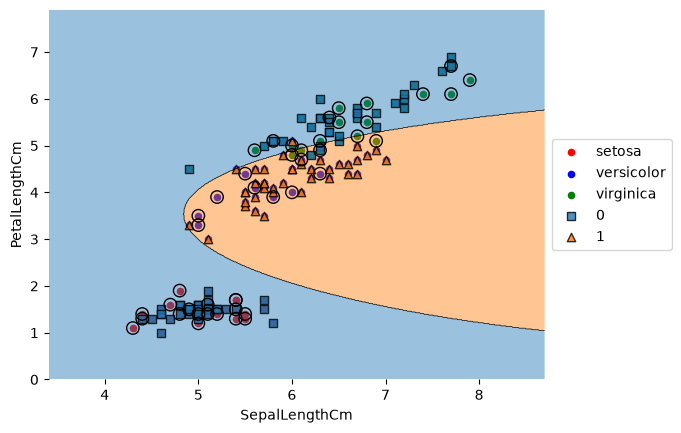

In [41]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

y = np.where(df.Species == 'Iris-versicolor', 1, 0)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(include_bias=False, degree=3)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LogisticRegression()),
])
pipe.fit(X_train, y_train)


y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

plot_decision_regions(X_train.values, y_train, pipe, X_highlight=X_test.values)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

In [42]:
from sklearn import tree

[[31  4]
 [ 1  9]]
accuracy:  0.8888888888888888


/home/aio/training/AI/LangchainDemos/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


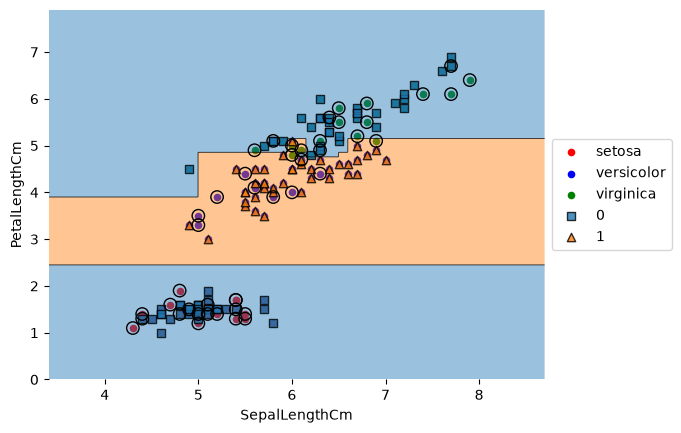

In [44]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

y = np.where(df.Species == 'Iris-versicolor', 1, 0)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

pipe = pipeline.Pipeline([
    #('poly', preprocessing.PolynomialFeatures(include_bias=False, degree=3)),
    #('scaler', preprocessing.StandardScaler()),
    ('est', tree.DecisionTreeClassifier()),
])
pipe.fit(X_train, y_train)


y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

plot_decision_regions(X_train.values, y_train, pipe, X_highlight=X_test.values)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

In [45]:
from sklearn import neighbors

[[31  4]
 [ 1  9]]
accuracy:  0.8888888888888888


/home/aio/training/AI/LangchainDemos/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


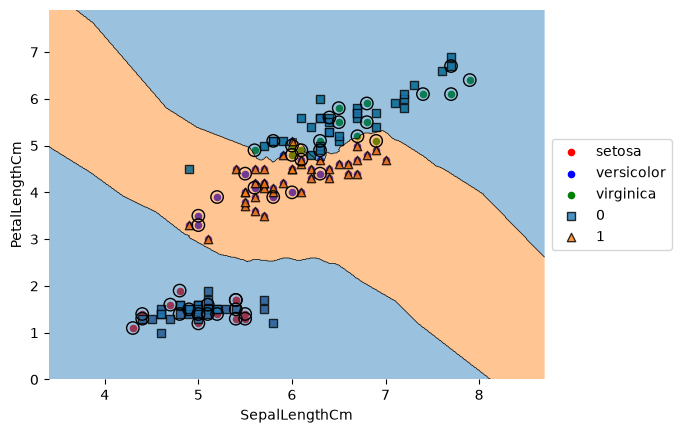

In [47]:
fig, ax = plt.subplots()
X = df[['SepalLengthCm', 'PetalLengthCm']]
X[df.Species == 'Iris-setosa'].plot.scatter(0, 1, color = 'red', ax = ax, label = 'setosa')
X[df.Species == 'Iris-versicolor'].plot.scatter(0, 1, color = 'blue', ax = ax, label='versicolor')
X[df.Species == 'Iris-virginica'].plot.scatter(0, 1, color = 'green', ax = ax, label = 'virginica')

y = np.where(df.Species == 'Iris-versicolor', 1, 0)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=123)

pipe = pipeline.Pipeline([
    #('poly', preprocessing.PolynomialFeatures(include_bias=False, degree=3)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', neighbors.KNeighborsClassifier()),
])
pipe.fit(X_train, y_train)


y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

plot_decision_regions(X_train.values, y_train, pipe, X_highlight=X_test.values)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))